##### Data preprocessing (Winter months - January)

##### Read in and read the pickle files (Electricity Price)

In [ ]:
import pickle
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

##### Part I

* Exploration of the price PDFs for **a specific day** of a **specific month (January)** in a **specific year**

In [ ]:
# Combined Data from 2013 - 2019 (7 years)

error_data_price = {}

for year in range(2013, 2021):
  with open(f'error_price_{year}.pickle', 'rb') as file:
    error_data_price[f'{year}'] = pickle.load(file)

ed = [error_data_price['2013'], error_data_price['2014'], error_data_price['2015'], error_data_price['2016'], error_data_price['2017'], error_data_price['2018'], error_data_price['2019']]

merged_error_price = pd.concat(ed, ignore_index = False)

merged_error_price = merged_error_price.reset_index()

In [ ]:
# Extract the month and create a new column
merged_error_price['month'] = merged_error_price['Date'].dt.month

# Extract the year and create a new column
merged_error_price['year'] = merged_error_price['Date'].dt.year

# Extract the month name and create a new column
merged_error_price['month_name'] = merged_error_price['Date'].dt.month_name()

# Extract the day of the month and create a new column
merged_error_price['day_of_month'] = merged_error_price['Date'].dt.day

# Extract the hour and create a new column
merged_error_price['hour'] = merged_error_price['Date'].dt.hour

# Extract the day of the week (numeric) and create a new column
merged_error_price['day_of_week_num'] = merged_error_price['Date'].dt.dayofweek

# Extract the day of the week (name) and create a new column
merged_error_price['day_of_week_name'] = merged_error_price['Date'].dt.day_name()

# Filter out data for the month of January only
merged_error_price_Jan = merged_error_price.loc[merged_error_price['month_name'] == 'January']

merged_error_price_Jan = merged_error_price_Jan.set_index('Date')

In [ ]:
# Day - 21st, Month - January, Years (2013 to 2019)

Jan_filtered_I_2013 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2013)]

Jan_filtered_I_2014 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2014)]

Jan_filtered_I_2015 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2015)]

Jan_filtered_I_2016 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2016)]

Jan_filtered_I_2017 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2017)]

Jan_filtered_I_2018 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2018)]

Jan_filtered_I_2019 = merged_error_price_Jan[(merged_error_price_Jan['day_of_month'] == 21) & (merged_error_price_Jan['year'] == 2019)]

In [ ]:
Jan_filtered_I_2013

,error_price,month,year,month_name,day_of_month,hour,day_of_week_num,day_of_week_name
Date,,,,,,,,
2013-01-21 00:00:00,1.089346,1,2013,January,21,0,0,Monday
2013-01-21 01:00:00,0.785704,1,2013,January,21,1,0,Monday
2013-01-21 02:00:00,0.005774,1,2013,January,21,2,0,Monday
2013-01-21 03:00:00,1.598238,1,2013,January,21,3,0,Monday
2013-01-21 04:00:00,5.198721,1,2013,January,21,4,0,Monday
2013-01-21 05:00:00,4.880998,1,2013,January,21,5,0,Monday
2013-01-21 06:00:00,4.250670,1,2013,January,21,6,0,Monday
2013-01-21 07:00:00,2.023999,1,2013,January,21,7,0,Monday
2013-01-21 08:00:00,1.775105,1,2013,January,21,8,0,Monday


In [ ]:
Jan_price_data = Jan_filtered_I_2019['error_price']

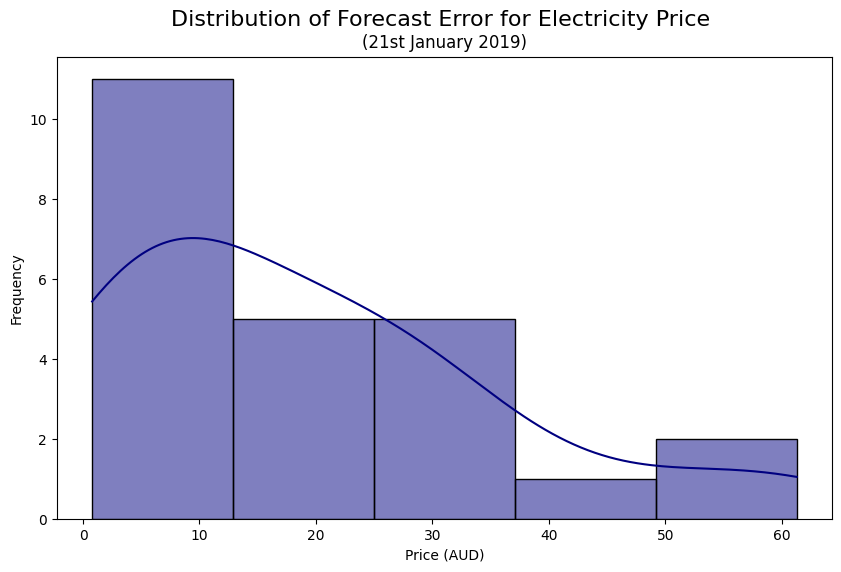

In [ ]:
# Price distribution plots

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame(Jan_price_data)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='error_price', bins=5, kde=True, color = 'navy')
plt.title('Distribution of Forecast Error for Electricity Price \n', fontsize=16)  # Adding \n for a line break
plt.xlabel('Price (AUD)')
plt.ylabel('Frequency')

# Add subtitle
plt.text(0.5, 1.02, '(21st January 2019)', ha='center', fontsize=12, transform=plt.gca().transAxes)

# Save the figure with high resolution
plt.savefig('Price Error distribution (January 2019).png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# List to store each run of the code in the next code cell
# Jan_load_data = Jan_filtered_I_X['price']. X is changed from 2013 to 2019

compiled_price_stats = []

In [ ]:
# Price Data filtered

Jan_price_data = Jan_filtered_I_2019['error_price']

In [ ]:
# PDF fitting and testing for Electricity price data

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Dictionary to store goodness-of-fit statistics
price_distribution_results = {}

# data
data = Jan_price_data

# Distributions to consider
distribution_list = ['norm', 'lognorm', 'skewnorm', 'gamma', 'cauchy', 'rayleigh', 'loggamma', 'beta']

# Iterate through distributions
for distribution in distribution_list:
    # Fit the data
    if distribution in ['norm', 'lognorm']:
        params = getattr(stats, distribution).fit(data)
        fitted_distribution = getattr(stats, distribution)(*params)
    else:
        params = getattr(stats, distribution).fit(data)
        fitted_distribution = getattr(stats, distribution)(*params[:-2], loc=params[-2], scale=params[-1])

    # Generate PDFs for the fitted distributions
    x = np.linspace(data.min(), data.max(), 100)
    pdf = fitted_distribution.pdf(x)

    # Perform goodness-of-fit tests
    ks_statistic, ks_p_value = stats.kstest(data, distribution, args=params)
    cvm_result_obj = stats.cramervonmises(data, fitted_distribution.cdf)

    # Extract statistic and p-value from CramerVonMisesResult object
    cvm_statistic, cvm_p_value = cvm_result_obj.statistic, cvm_result_obj.pvalue

    price_distribution_results[distribution.capitalize()] = {'KS': [ks_statistic, ks_p_value], 'CvM': [cvm_statistic, cvm_p_value]}

# Display goodness-of-fit results
for distribution, results in price_distribution_results.items():
    print(f'{distribution}: KS Statistic = {results["KS"][0]}, p-value = {results["KS"][1]}, CvM Statistic = {results["CvM"][0]}, p-value = {results["CvM"][1]}')

compiled_price_stats.append(price_distribution_results)

/usr/local/lib/python3.10/dist-packages/scipy/stats/_continuous_distns.py:719: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


Norm: KS Statistic = 0.13917919127045314, p-value = 0.6902302376572589, CvM Statistic = 0.11908720724750323, p-value = 0.5022658545335694
Lognorm: KS Statistic = 0.12750651514403166, p-value = 0.7844015461971279, CvM Statistic = 0.055208084239455, p-value = 0.8487409741274311
Skewnorm: KS Statistic = 0.15333649156870183, p-value = 0.5728435690828915, CvM Statistic = 0.1002389697552009, p-value = 0.5874971916438102
Gamma: KS Statistic = 0.1380782718288397, p-value = 0.6993474404919418, CvM Statistic = 0.08005910968059006, p-value = 0.695975174980312
Cauchy: KS Statistic = 0.20792841333022438, p-value = 0.21791026503513722, CvM Statistic = 0.17835662426500826, p-value = 0.315035096540474
Rayleigh: KS Statistic = 0.16938670470354975, p-value = 0.4475968289022002, CvM Statistic = 0.13252123171910357, p-value = 0.45018184702560204
Loggamma: KS Statistic = 0.14023490626692736, p-value = 0.6814650989978794, CvM Statistic = 0.12644446202320703, p-value = 0.4729127258475646
Beta: KS Statistic =

In [ ]:
# Checking the length of 'compiled_price_stats'. The length should be 7.

print(len(compiled_price_stats))

7


In [ ]:
# Convert list of dictionaries to DataFrame
# Set display options
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

# Convert to DataFrame
df_b = pd.DataFrame(compiled_price_stats)

# Write DataFrame to CSV
df_b.to_csv('compiled_priceerror_stats.csv', index=False)

* Result plotting for each PDF **(KS test & CvM)** for each year (2013 to 2019)

In [ ]:
# Import the csv result

compiled_stats_price = pd.read_csv('compiled_priceerror_stats.csv')

In [ ]:
import ast

# Function to expand dictionary values into separate columns
def expand_dict_values(row, column_name):
    expanded_values = ast.literal_eval(row[column_name])
    for key, value in expanded_values.items():
        for i, v in enumerate(value):
            row[f"{column_name}_{key}_{i+1}"] = v
    return row

# Convert the dictionary to a DataFrame
df = pd.DataFrame(compiled_stats_price)

# Iterate over each PDF column and expand values
for pdf in df.columns:
    df = df.apply(lambda row: expand_dict_values(row, pdf), axis=1)

# Drop the original PDF columns
df.drop(columns=list(compiled_stats_price.keys()), inplace=True)

# Iterate over column names and replace '1' with 'stats' and '2' with 'pvalues'
df.columns = df.columns.str.replace('1', 'stats').str.replace('2', 'pvalues')

# Print the updated DataFrame
print(df)

   Norm_KS_stats  Norm_KS_pvalues  Norm_CvM_stats  Norm_CvM_pvalues  Lognorm_KS_stats  Lognorm_KS_pvalues  Lognorm_CvM_stats  Lognorm_CvM_pvalues  Skewnorm_KS_stats  Skewnorm_KS_pvalues  Skewnorm_CvM_stats  Skewnorm_CvM_pvalues  Gamma_KS_stats  Gamma_KS_pvalues  Gamma_CvM_stats  Gamma_CvM_pvalues  Cauchy_KS_stats  Cauchy_KS_pvalues  Cauchy_CvM_stats  Cauchy_CvM_pvalues  Rayleigh_KS_stats  Rayleigh_KS_pvalues  Rayleigh_CvM_stats  Rayleigh_CvM_pvalues  Loggamma_KS_stats  Loggamma_KS_pvalues  Loggamma_CvM_stats  Loggamma_CvM_pvalues  Beta_KS_stats  Beta_KS_pvalues  Beta_CvM_stats  Beta_CvM_pvalues
0       0.191405         0.302773        0.257072          0.179660          0.383399            0.001105           1.041525             0.001681           0.275704             0.041928            0.532887              0.032011        0.164256          0.486159         0.174808           0.323574         0.264635           0.056708          0.307486            0.128437           0.202963        

In [ ]:
# Filter the 'pvalues' columns

pvalues_columns = [col for col in df.columns if 'pvalues' in col]

# Subset the DataFrame with the filtered column names
df_pvalues = df[pvalues_columns].copy()

# Create a range of datetime values from 2013 to 2019
years = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Add the 'Year' column to the DataFrame
df_pvalues.loc[:, 'Year'] = years

# Rearrange the columns so that 'Year' is the first column
df_pvalues = df_pvalues[['Year'] + [col for col in df_pvalues.columns if col != 'Year']]

# Print the subsetted DataFrame
print(df_pvalues)

   Year  Norm_KS_pvalues  Norm_CvM_pvalues  Lognorm_KS_pvalues  Lognorm_CvM_pvalues  Skewnorm_KS_pvalues  Skewnorm_CvM_pvalues  Gamma_KS_pvalues  Gamma_CvM_pvalues  Cauchy_KS_pvalues  Cauchy_CvM_pvalues  Rayleigh_KS_pvalues  Rayleigh_CvM_pvalues  Loggamma_KS_pvalues  Loggamma_CvM_pvalues  Beta_KS_pvalues  Beta_CvM_pvalues
0  2013         0.302773          0.179660            0.001105             0.001681             0.041928              0.032011          0.486159           0.323574           0.056708            0.128437             0.241288              0.139328             0.293690              0.176475         0.009020          0.010463
1  2014         0.448298          0.557837            0.448286             0.557825             0.732517              0.889756          0.312993           0.435222           0.590336            0.529741             0.013630              0.054863             0.876212              0.925605         0.788534          0.896695
2  2015         0.885733    

In [ ]:
# Reshaping the 'p_values' column

import pandas as pd

# Reshape the DataFrame to long format
df_long = pd.melt(df_pvalues, id_vars='Year', var_name='PDF', value_name='Value')

# Extract PDF type and Stat type from 'PDF' column
df_long[['PDF', 'Pvalue', '_']] = df_long['PDF'].str.split('_', expand=True)

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_pvalues = df_long.pivot_table(index=['Year', 'PDF'], columns='Pvalue', values='Value').reset_index()

# Rename the columns
df_pivot_pvalues.columns.name = None
df_pivot_pvalues.columns = ['Year', 'PDF', 'CvM_pvalues', 'KS_pvalues']

print(df_pivot_pvalues)

    Year       PDF  CvM_pvalues  KS_pvalues
0   2013      Beta     0.010463    0.009020
1   2013    Cauchy     0.128437    0.056708
2   2013     Gamma     0.323574    0.486159
3   2013  Loggamma     0.176475    0.293690
4   2013   Lognorm     0.001681    0.001105
5   2013      Norm     0.179660    0.302773
6   2013  Rayleigh     0.139328    0.241288
7   2013  Skewnorm     0.032011    0.041928
8   2014      Beta     0.896695    0.788534
9   2014    Cauchy     0.529741    0.590336
10  2014     Gamma     0.435222    0.312993
11  2014  Loggamma     0.925605    0.876212
12  2014   Lognorm     0.557825    0.448286
13  2014      Norm     0.557837    0.448298
14  2014  Rayleigh     0.054863    0.013630
15  2014  Skewnorm     0.889756    0.732517
16  2015      Beta     0.894733    0.870528
17  2015    Cauchy     0.720573    0.789003
18  2015     Gamma     0.889254    0.895492
19  2015  Loggamma     0.889781    0.889468
20  2015   Lognorm     0.890592    0.901630
21  2015      Norm     0.887077 

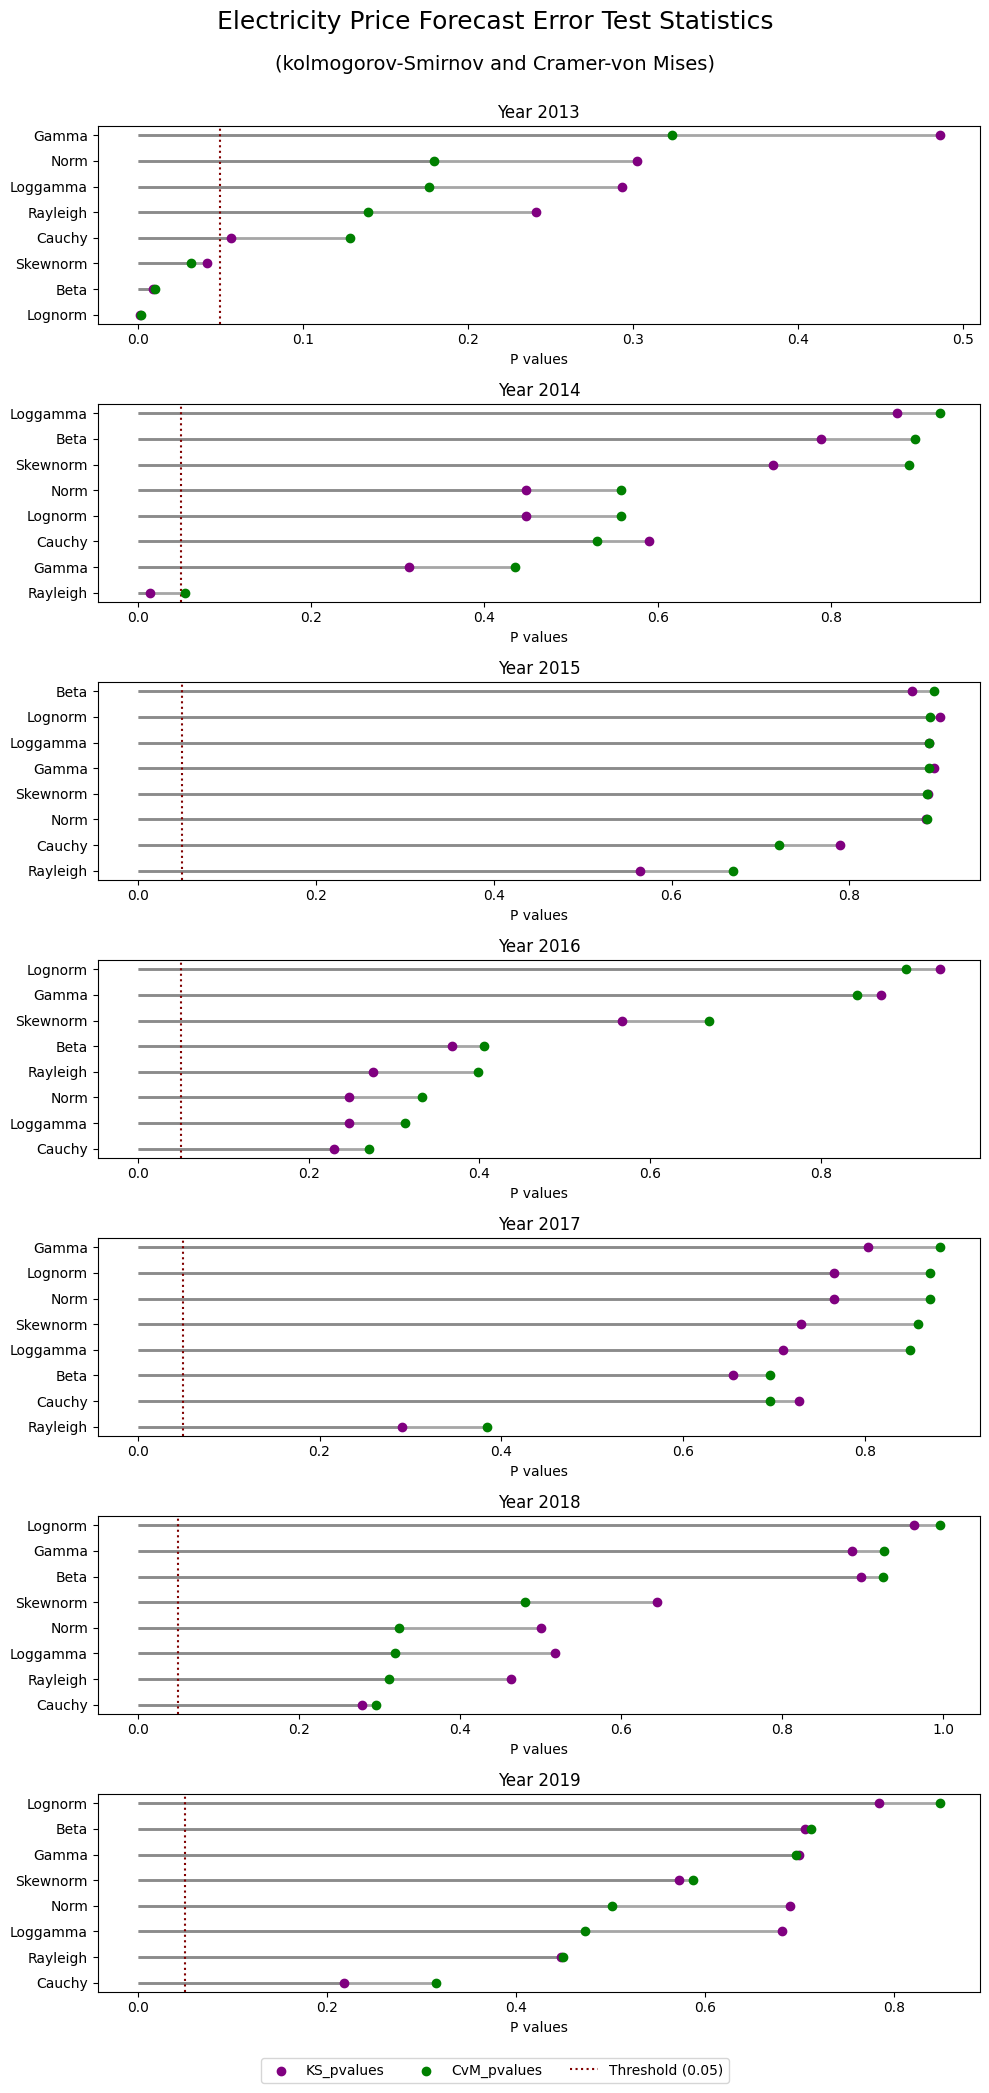

In [ ]:
# Plot of the 'Goodness of fit' for each PDF

# Convert data to DataFrame
df_2 = df_pivot_pvalues

# Sort DataFrame by 'KS_pvalues' and 'CvM_pvalues' in descending order
df_sorted = df_2.sort_values(by=['CvM_pvalues', 'KS_pvalues'], ascending=True)

# Create a lollipop plot
fig, axs = plt.subplots(7, 1, figsize=(10, 20))

# Iterate over each year
for i, year in enumerate(df_2['Year'].unique()):
    # Filter data for the current year
    year_data = df_sorted[df_sorted['Year'] == year]

    # Set up subplot
    ax = axs[i]

    # Plot the KS pvalues
    ax.scatter(year_data['KS_pvalues'], year_data['PDF'], color='purple', label='KS_pvalues', zorder=5)
    for _, row in year_data.iterrows():
        ax.hlines(row['PDF'], 0, row['KS_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Plot the CvM pvalues
    ax.scatter(year_data['CvM_pvalues'], year_data['PDF'], color='green', label='CvM_pvalues', zorder=5)
    for _, row in year_data.iterrows():
        ax.hlines(row['PDF'], 0, row['CvM_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Set labels and title
    ax.set_xlabel('P values')
    ax.set_ylabel('')
    ax.set_title(f'Year {year}')

    # Place a vertical dotted line at the value of 0.05
    ax.axvline(x=0.05, color='maroon', linestyle='dotted', label='Threshold (0.05)')

    # Disable legend
    ax.legend().remove()

# Add a title and subtitle to the figure
fig.suptitle('Electricity Price Forecast Error Test Statistics', fontsize=18, y=1.02)
fig.text(0.5, 0.99, '(kolmogorov-Smirnov and Cramer-von Mises)', ha='center', fontsize=14)

# Add legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('Error_Price_test_stats(pvalues_2013_2019).png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Filter the 'stats' columns

stats_columns = [col for col in df.columns if 'stats' in col]

# Subset the DataFrame with the filtered column names
df_stats = df[stats_columns].copy()

# Create a range of datetime values from 2013 to 2019
years = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Add the 'Year' column to the DataFrame
df_stats.loc[:, 'Year'] = years

# Rearrange the columns so that 'Year' is the first column
df_stats = df_stats[['Year'] + [col for col in df_stats.columns if col != 'Year']]

# Print the subsetted DataFrame
print(df_stats)

   Year  Norm_KS_stats  Norm_CvM_stats  Lognorm_KS_stats  Lognorm_CvM_stats  Skewnorm_KS_stats  Skewnorm_CvM_stats  Gamma_KS_stats  Gamma_CvM_stats  Cauchy_KS_stats  Cauchy_CvM_stats  Rayleigh_KS_stats  Rayleigh_CvM_stats  Loggamma_KS_stats  Loggamma_CvM_stats  Beta_KS_stats  Beta_CvM_stats
0  2013       0.191405        0.257072          0.383399           1.041525           0.275704            0.532887        0.164256         0.174808         0.264635          0.307486           0.202963            0.295061           0.193000            0.259701       0.325970        0.723973
1  2014       0.169291        0.106429          0.169293           0.106432           0.134036            0.048489        0.189650         0.136723         0.151203          0.112640           0.313310            0.443156           0.114526            0.042156       0.126970        0.047310
2  2015       0.112984        0.048939          0.110270           0.048348           0.112534            0.048843        0.

In [ ]:
# Reshaping the stats column

# Reshape the DataFrame to long format
df_long = pd.melt(df_stats, id_vars='Year', var_name='PDF', value_name='Value')

# Extract PDF type and Stat type from 'PDF' column
df_long[['PDF', 'Stat', '_']] = df_long['PDF'].str.split('_', expand=True)

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_kstats = df_long.pivot_table(index=['Year', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_kstats.columns.name = None
df_pivot_kstats.columns = ['Year', 'PDF', 'CvM_stats', 'KS_stats']

# Arrange PDFs in ascending order of KS_stats and CvM_stats for each year
df_pivot_kstats = df_pivot_kstats.groupby('Year').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)

# Write to a csv file
df_pivot_kstats.to_csv('Error_Price_KS_CvM_stats_2013-2019.csv')

print(df_pivot_kstats)

    Year       PDF  CvM_stats  KS_stats
0   2013     Gamma   0.174808  0.164256
1   2013      Norm   0.257072  0.191405
2   2013  Loggamma   0.259701  0.193000
3   2013  Rayleigh   0.295061  0.202963
4   2013    Cauchy   0.307486  0.264635
5   2013  Skewnorm   0.532887  0.275704
6   2013      Beta   0.723973  0.325970
7   2013   Lognorm   1.041525  0.383399
8   2014  Loggamma   0.042156  0.114526
9   2014      Beta   0.047310  0.126970
10  2014  Skewnorm   0.048489  0.134036
11  2014      Norm   0.106429  0.169291
12  2014   Lognorm   0.106432  0.169293
13  2014    Cauchy   0.112640  0.151203
14  2014     Gamma   0.136723  0.189650
15  2014  Rayleigh   0.443156  0.313310
16  2015      Beta   0.047645  0.115421
17  2015   Lognorm   0.048348  0.110270
18  2015  Loggamma   0.048484  0.112364
19  2015     Gamma   0.048573  0.111342
20  2015  Skewnorm   0.048843  0.112534
21  2015      Norm   0.048939  0.112984
22  2015    Cauchy   0.075883  0.126909
23  2015  Rayleigh   0.084811  0.154383


##### Part II

* Hourly Analysis (Price)

In [ ]:
# Select the price data for each hour

# Create a copy of the dataframe
Jan_data = merged_error_price_Jan.copy()

# Initialize an empty dictionary to store the load demand and price data for each hour (Jan)
hourly_data_Jan = {}

# Iterate through hours from 0 to 23
for hour in range(24):
    # Filter the data for the current hour and store it in the dictionary (The value of each key is a the Load demand)
    hourly_data_Jan[f'Hour_{hour}'] = Jan_data[Jan_data['hour'] == hour]['error_price']

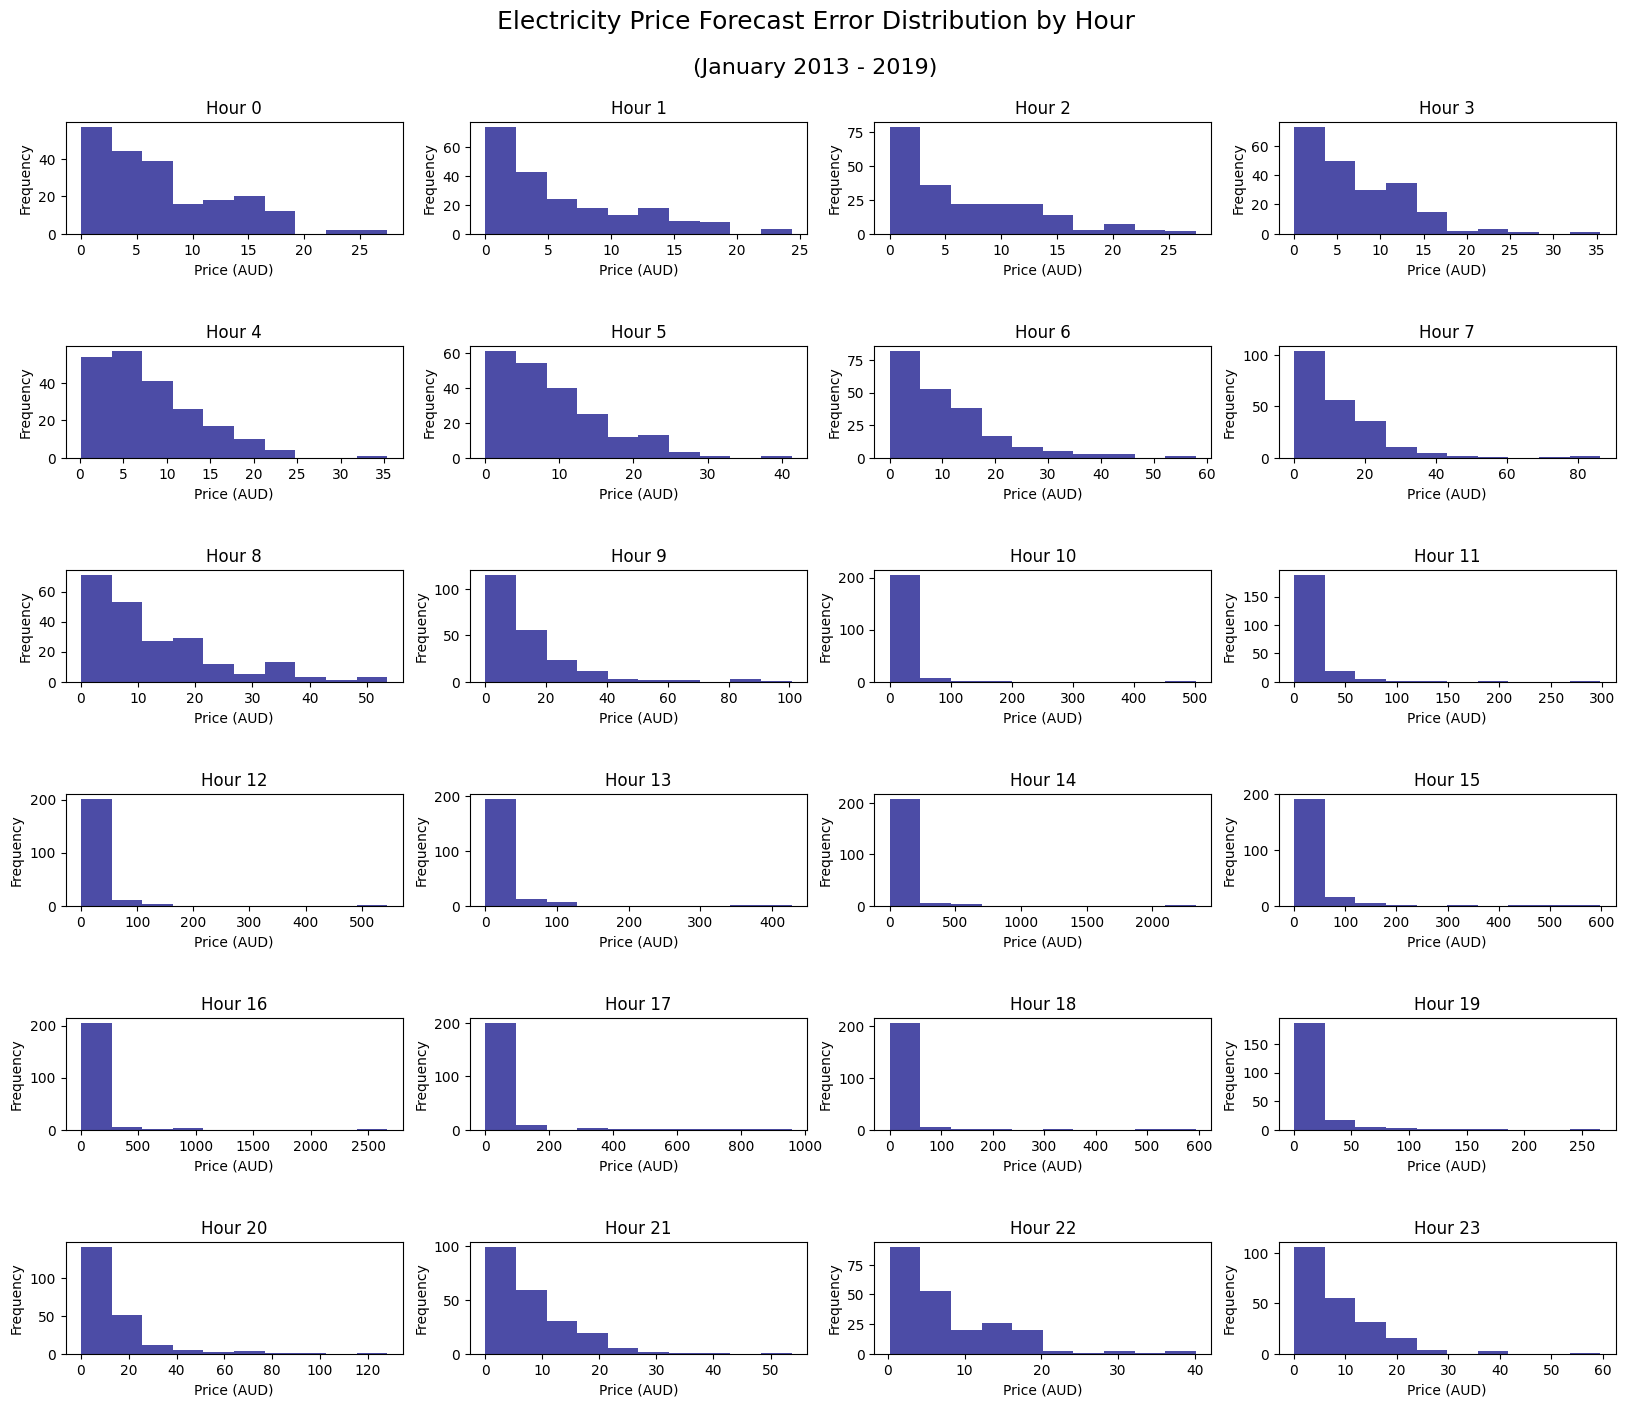

In [ ]:
# Plot type I (Histogram)

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours and create histograms
for hour, ax in zip(range(24), axes.flatten()):
    price_data = hourly_data_Jan[f'Hour_{hour}']
    ax.hist(price_data, bins=10, color='navy', alpha=0.7)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Price (AUD)')
    ax.set_ylabel('Frequency')

# Add a title and subtitle to the figure
fig.suptitle('Electricity Price Forecast Error Distribution by Hour', fontsize=18, y=0.95)
fig.text(0.5, 0.91, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_priceerror_distribution.png', dpi=300, bbox_inches='tight')

# Show the histograms
plt.show()

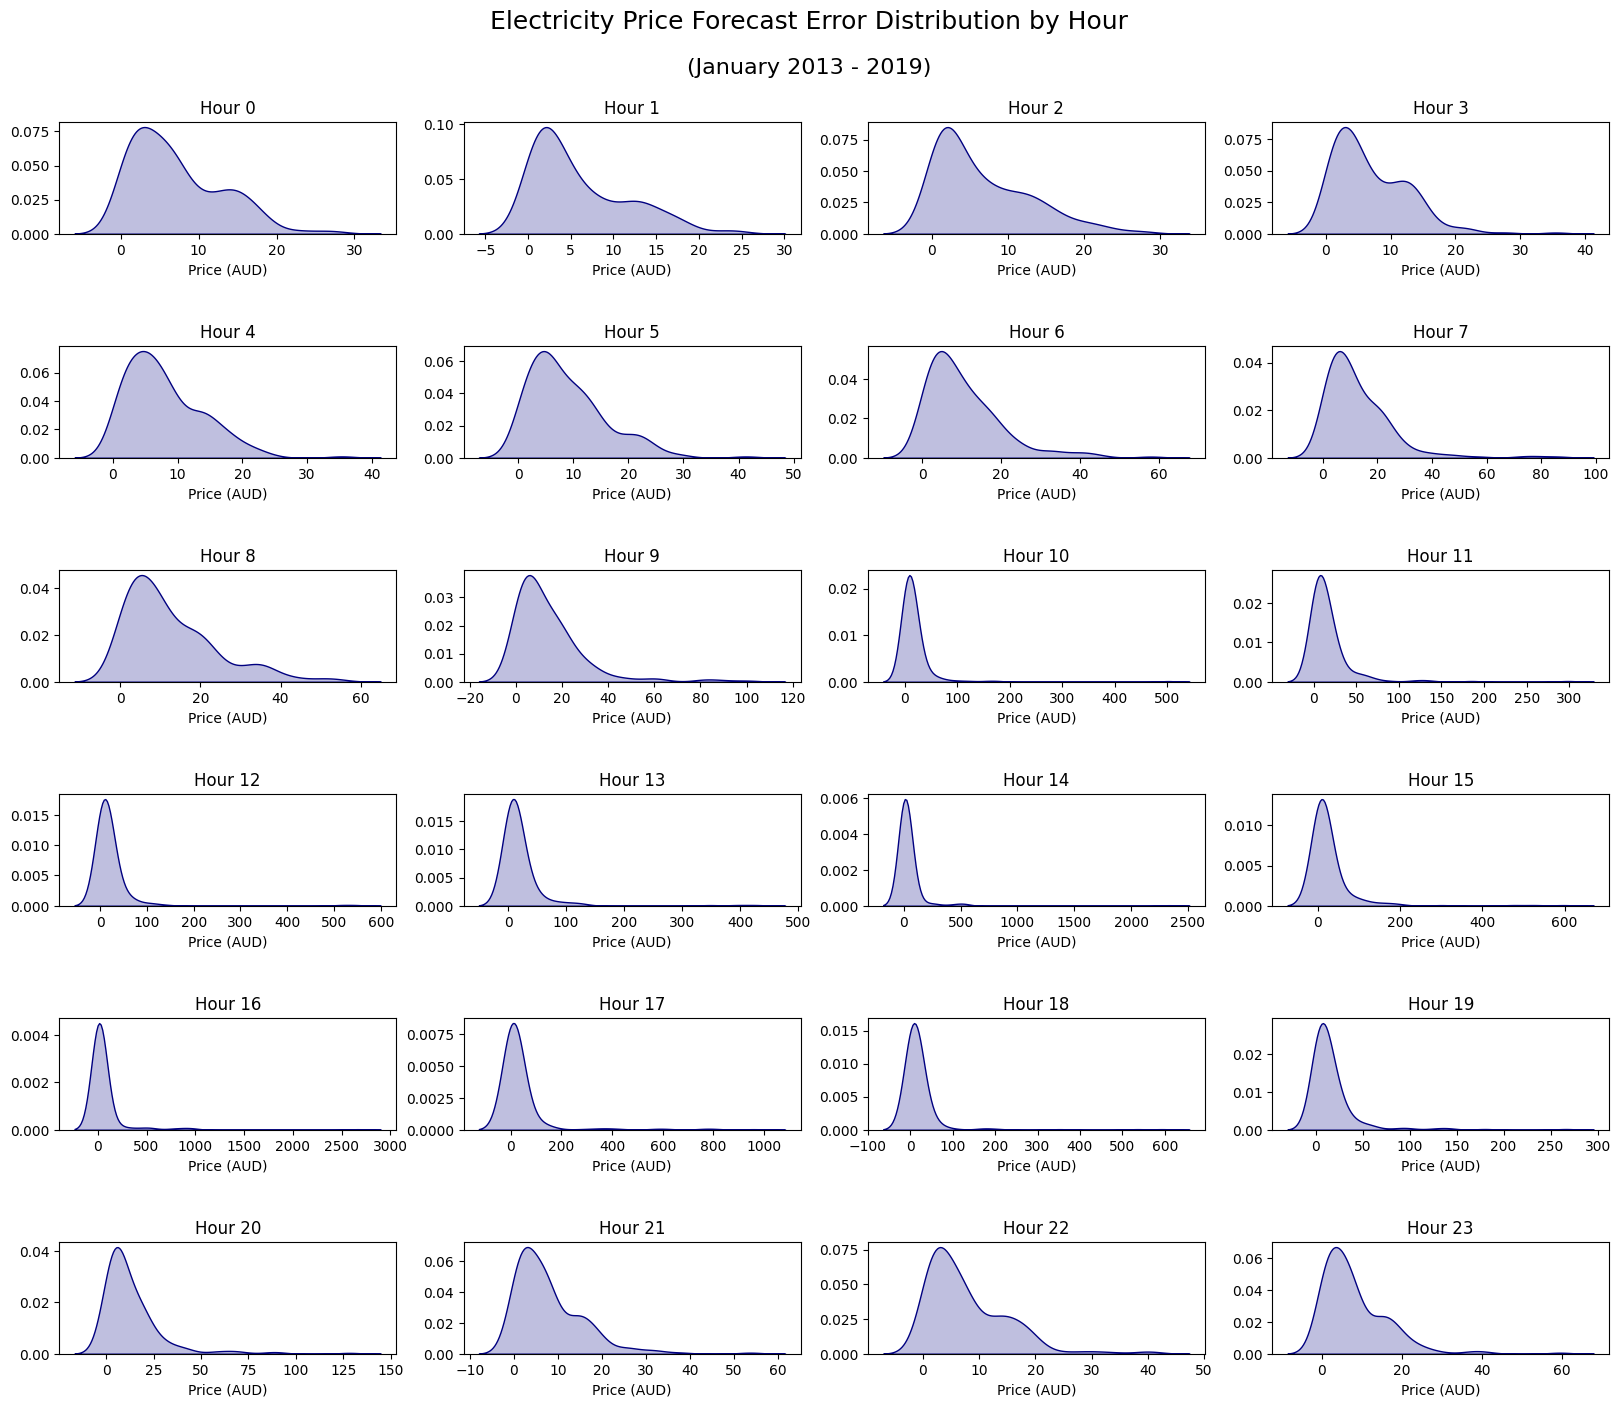

In [ ]:
# Plot type II (kernel density plot)

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours and create density plots
for hour, ax in zip(range(24), axes.flatten()):
    price_data = hourly_data_Jan[f'Hour_{hour}']
    sns.kdeplot(price_data, color='navy', fill=True, ax=ax, legend = False)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Price (AUD)')
    ax.set_ylabel('')

# Add a title and subtitle to the figure
fig.suptitle('Electricity Price Forecast Error Distribution by Hour', fontsize=18, y=0.95)
fig.text(0.5, 0.91, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_priceerror_distribution_density.png', dpi=300, bbox_inches='tight')

# Show the density plots
plt.show()

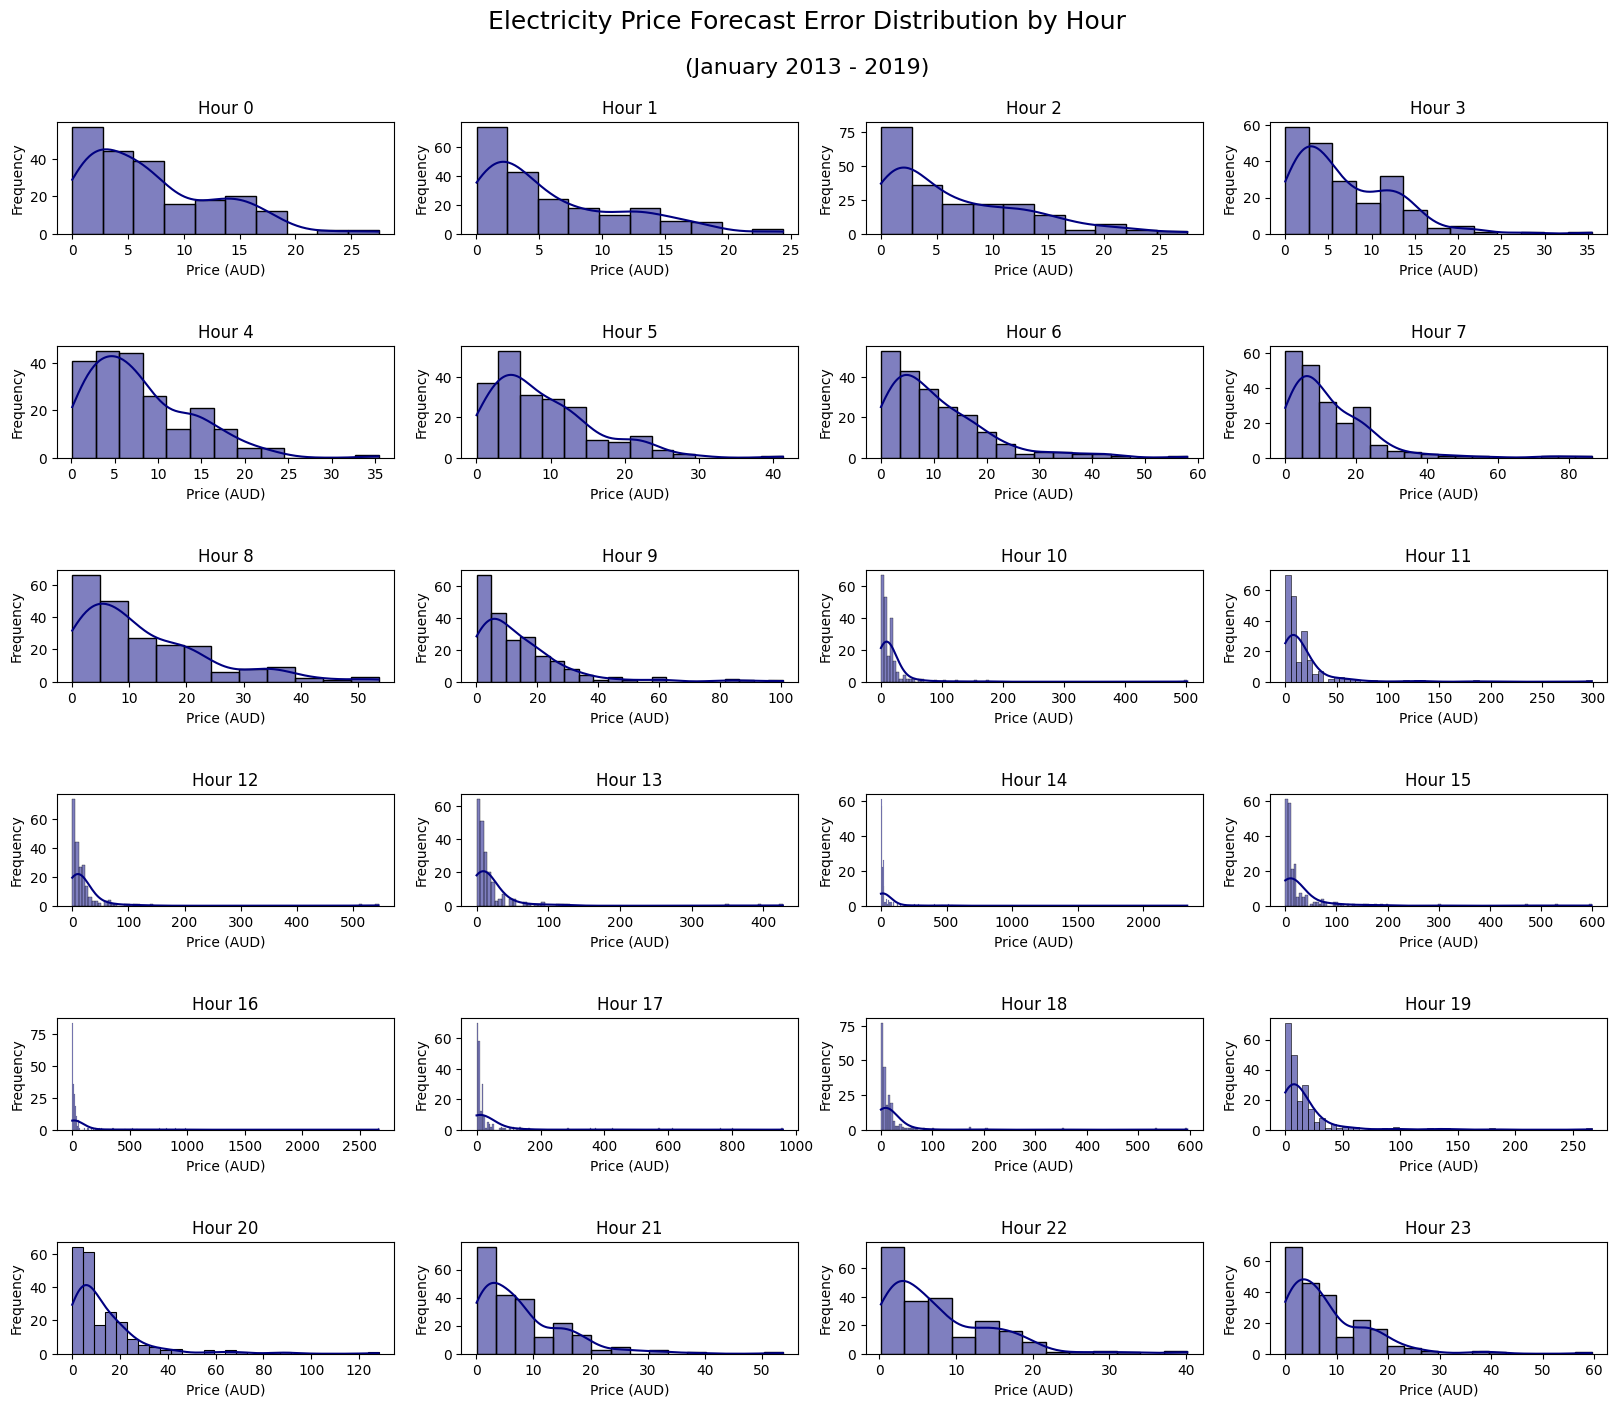

In [ ]:
# Plot type III (Histogram and kernel density plot)

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours and create histograms with KDE plots
for hour, ax in zip(range(24), axes.flatten()):
    price_data = hourly_data_Jan[f'Hour_{hour}']
    sns.histplot(price_data, kde=True, color='navy', ax=ax, legend = False)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Price (AUD)')
    ax.set_ylabel('Frequency')

# Add a title and subtitle to the figure
fig.suptitle('Electricity Price Forecast Error Distribution by Hour', fontsize=18, y=0.95)
fig.text(0.5, 0.91, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_priceerror_distribution_hist_and_density.png', dpi=300, bbox_inches='tight')

# Show the combined histogram and KDE plots
plt.show()

##### Goodness of fit (Price) - Testing the Norm distribution only

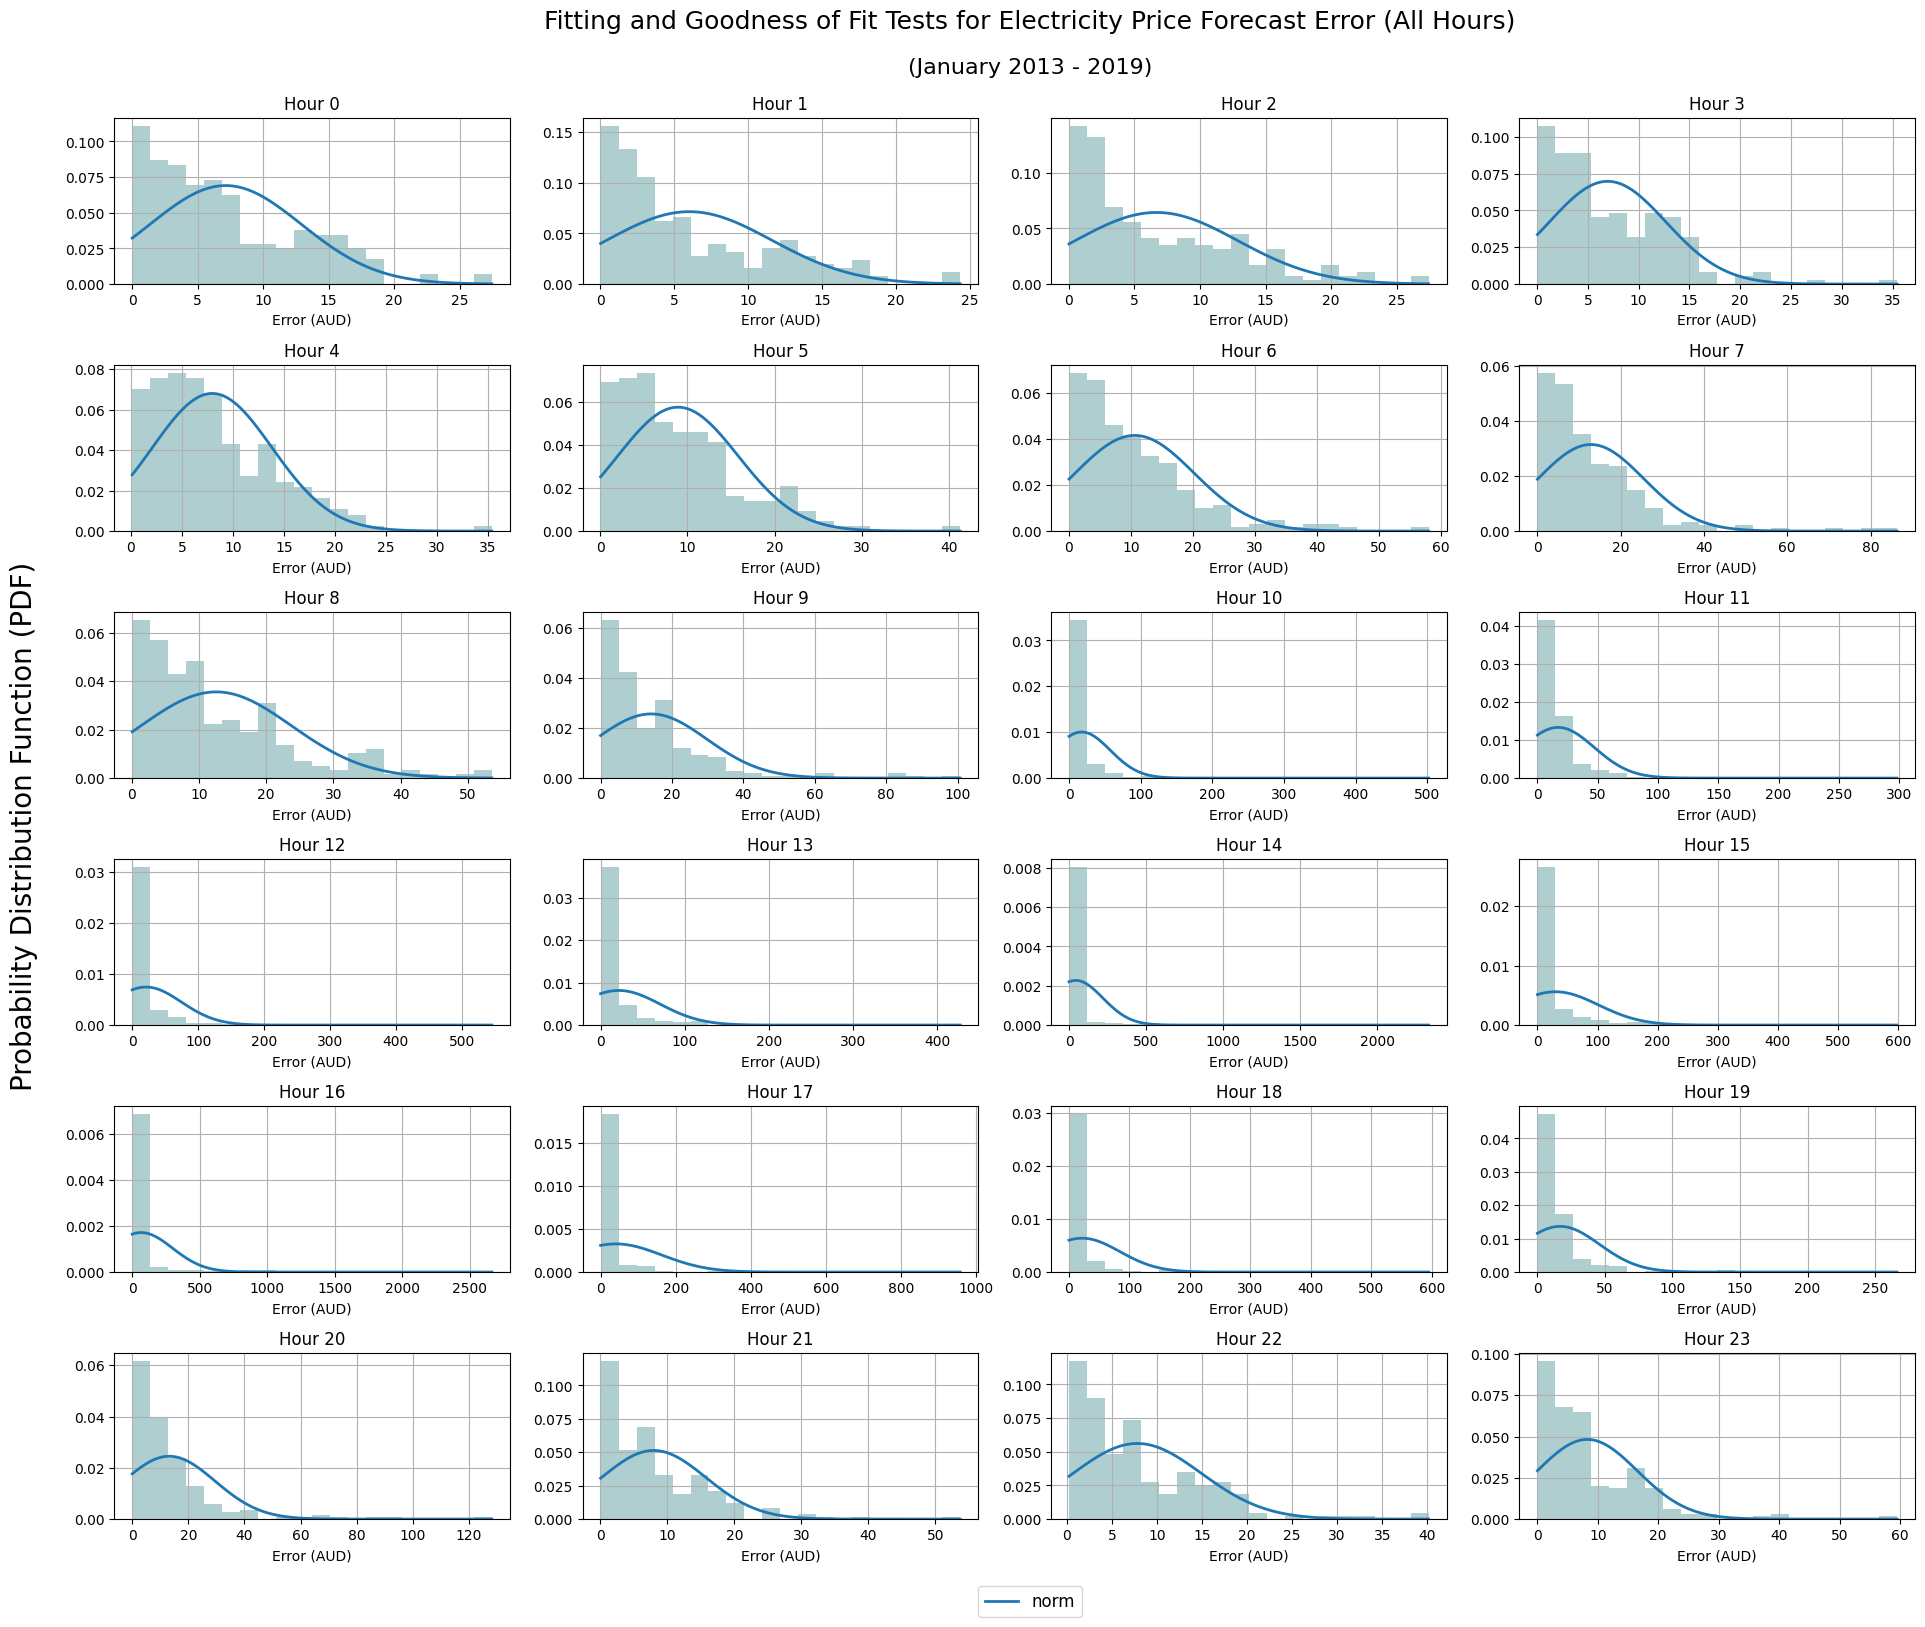

In [ ]:
# Dictionary to store goodness-of-fit statistics for each hour
price_distribution_results = {f'Hour_{hour}': {} for hour in range(24)}

# New dictionary to store parameters of each PDF fitted at each hour
pdf_parameters_price = {f'Hour_{hour}': {} for hour in range(24)}

# Distributions to consider
distribution_list = ['norm']

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours
for hour, ax in zip(range(24), axes.flatten()):
    # Extract the price data for the current hour
    hour_data = hourly_data_Jan[f'Hour_{hour}']

    # Dictionary to store parameters for this hour
    pdf_parameters_hour = {}

    # Iterate through distributions
    for distribution in distribution_list:
        # Fit the data
        if distribution in ['norm', 'lognorm']:
            params = getattr(stats, distribution).fit(hour_data)
            fitted_distribution = getattr(stats, distribution)(*params)
        else:
            params = getattr(stats, distribution).fit(hour_data)
            fitted_distribution = getattr(stats, distribution)(*params[:-2], loc=params[-2], scale=params[-1])

        # Store parameters
        pdf_parameters_hour[distribution] = params

        # Generate PDFs for the fitted distributions
        x = np.linspace(hour_data.min(), hour_data.max(), 100)
        pdf = fitted_distribution.pdf(x)

        # Perform goodness-of-fit tests
        ks_statistic, ks_p_value = stats.kstest(hour_data, distribution, args=params)
        cvm_result_obj = stats.cramervonmises(hour_data, fitted_distribution.cdf)

        # Extract statistic and p-value from CramerVonMisesResult object
        cvm_statistic, cvm_p_value = cvm_result_obj.statistic, cvm_result_obj.pvalue

        price_distribution_results[f'Hour_{hour}'][distribution.capitalize()] = {'KS': [ks_statistic, ks_p_value], 'CvM': [cvm_statistic, cvm_p_value]}

        # Plot the histogram of the data and the fitted distribution
        ax.hist(hour_data, bins=20, density=True, alpha=0.5, color='cadetblue')
        ax.plot(x, pdf, label=distribution.capitalize(), linewidth=2.0)
        ax.set_title(f'Hour {hour}')
        ax.set_xlabel('Error (AUD)')
        ax.set_ylabel('')
        ax.legend().set_visible(False)
        ax.grid()

    # Store parameters for this hour
    pdf_parameters_price[f'Hour_{hour}'] = pdf_parameters_hour

# Add a y-axis label to the overall figure
fig.text(-0.01, 0.5, 'Probability Distribution Function (PDF)', va='center', rotation='vertical', fontsize=20)

# List of labels for the plots
labels = distribution_list

# Add an overall legend to the figure
fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=len(labels), fontsize=12)

# Add a title and subtitle to the figure
fig.suptitle('Fitting and Goodness of Fit Tests for Electricity Price Forecast Error (All Hours)', fontsize=18, y=1.01)
fig.text(0.5, 0.97, '(January 2013 - 2019)', ha='center', fontsize=16)

# Adjust the layout to make space for the overall legend
fig.tight_layout(rect=[0.01, 0.03, 0.95, 0.99])

# Save the figure with high resolution
plt.savefig('Error_Price_Fitting_and_Goodness_of_Fit_All_Hours.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Price distribution results

# Convert to DataFrame
df_price_jan = pd.DataFrame(price_distribution_results).T

# Write DataFrame to CSV
df_price_jan.to_csv('hourly_priceerror_distribution_results.csv')

In [ ]:
df_price_jan

,Norm
Hour_0,"{'KS': [0.12201487697875157, 0.003498159637669..."
Hour_1,"{'KS': [0.15442432739059248, 7.719111130332525..."
Hour_2,"{'KS': [0.15621966186173253, 6.085635487022537..."
Hour_3,"{'KS': [0.13384773310310333, 0.000965240787423..."
Hour_4,"{'KS': [0.11637833464415248, 0.006192895940161..."
Hour_5,"{'KS': [0.12201608235075284, 0.003497722216518..."
Hour_6,"{'KS': [0.13470763214790077, 0.000874909242707..."
Hour_7,"{'KS': [0.15562671308350157, 4.682547126028625..."
Hour_8,"{'KS': [0.14785365076251972, 0.000132306086877..."
Hour_9,"{'KS': [0.18222007921203548, 8.888277194641429..."


In [ ]:
import ast

# Function to expand dictionary values into separate columns
def expand_dict_values(row, column_name):
    expanded_values = row[column_name]

    for key, value in expanded_values.items():
        for i, v in enumerate(value):
            row[f"{column_name}_{key}_{i+1}"] = v
    return row

# Convert the dictionary to a DataFrame
df = pd.DataFrame(df_price_jan)

# Iterate over each PDF column and expand values
for pdf in df.columns:
    df = df.apply(lambda row: expand_dict_values(row, pdf), axis=1)

# Drop the original PDF columns
df.drop(columns=list(df_price_jan.keys()), inplace=True)

# Iterate over column names and replace '1' with 'stats' and '2' with 'pvalues'
df.columns = df.columns.str.replace('1', 'stats').str.replace('2', 'pvalues')

# Print the updated DataFrame
print(df)

         Norm_KS_stats  Norm_KS_pvalues  Norm_CvM_stats  Norm_CvM_pvalues
Hour_0        0.122015     3.498160e-03        0.942022      3.322679e-03
Hour_1        0.154424     7.719111e-05        1.631334      8.292064e-05
Hour_2        0.156220     6.085635e-05        1.352047      3.650810e-04
Hour_3        0.133848     9.652408e-04        0.924243      3.661503e-03
Hour_4        0.116378     6.192896e-03        0.713680      1.172194e-02
Hour_5        0.122016     3.497722e-03        0.779157      8.138089e-03
Hour_6        0.134708     8.749092e-04        1.214969      7.597680e-04
Hour_7        0.155627     4.682547e-05        1.655968      7.291281e-05
Hour_8        0.147854     1.323061e-04        1.270967      5.633786e-04
Hour_9        0.182220     8.888277e-07        2.080821      7.801446e-06
Hour_10       0.328463     2.354697e-21        7.434313      6.030227e-10
Hour_11       0.283099     7.013510e-16        5.384564      2.036359e-10
Hour_12       0.347018     7.486010e-2

In [ ]:
# Filtering the 'pvalues' columns

pvalues_columns = [col for col in df.columns if 'pvalues' in col]

# Subset the DataFrame with the filtered column names
df_pvalues = df[pvalues_columns].copy()

# Create a range of datetime values from 2013 to 2019
hours = ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']

# Add the 'Year' column to the DataFrame
df_pvalues.loc[:, 'Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
df_pvalues = df_pvalues[['Hour'] + [col for col in df_pvalues.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(df_pvalues)

        Hour  Norm_KS_pvalues  Norm_CvM_pvalues
Hour_0    H0     3.498160e-03      3.322679e-03
Hour_1    H1     7.719111e-05      8.292064e-05
Hour_2    H2     6.085635e-05      3.650810e-04
Hour_3    H3     9.652408e-04      3.661503e-03
Hour_4    H4     6.192896e-03      1.172194e-02
Hour_5    H5     3.497722e-03      8.138089e-03
Hour_6    H6     8.749092e-04      7.597680e-04
Hour_7    H7     4.682547e-05      7.291281e-05
Hour_8    H8     1.323061e-04      5.633786e-04
Hour_9    H9     8.888277e-07      7.801446e-06
Hour_10  H10     2.354697e-21      6.030227e-10
Hour_11  H11     7.013510e-16      2.036359e-10
Hour_12  H12     7.486010e-24      4.050171e-11
Hour_13  H13     1.694003e-21      2.012412e-11
Hour_14  H14     3.983144e-32      9.619467e-10
Hour_15  H15     2.010693e-22      8.365875e-11
Hour_16  H16     6.865658e-34      1.337368e-09
Hour_17  H17     2.525657e-28      3.135202e-10
Hour_18  H18     1.688010e-26      2.736563e-09
Hour_19  H19     8.161443e-16      7.013

In [ ]:
# Reshaping to a 'long' format

# Reshape the DataFrame to long format
df_long = pd.melt(df_pvalues, id_vars='Hour', var_name='PDF', value_name='Value')

# Convert 'Hour' column to categorical type to preserve order
df_long['Hour'] = pd.Categorical(df_long['Hour'], categories=['H{}'.format(i) for i in range(24)], ordered=True)

# Splitting the PDF column into two separate columns
pdf_split = df_long['PDF'].str.split('_', expand=True)

# Assigning the split columns to 'PDF' and 'Stat'
df_long['PDF'] = pdf_split[0]
df_long['Stat'] = pdf_split[1]

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_pvalues = df_long.pivot_table(index=['Hour', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_pvalues.columns.name = None
df_pivot_pvalues.columns = ['Hour', 'PDF', 'CvM_pvalues', 'KS_pvalues']

print(df_pivot_pvalues)

   Hour   PDF   CvM_pvalues    KS_pvalues
0    H0  Norm  3.322679e-03  3.498160e-03
1    H1  Norm  8.292064e-05  7.719111e-05
2    H2  Norm  3.650810e-04  6.085635e-05
3    H3  Norm  3.661503e-03  9.652408e-04
4    H4  Norm  1.172194e-02  6.192896e-03
5    H5  Norm  8.138089e-03  3.497722e-03
6    H6  Norm  7.597680e-04  8.749092e-04
7    H7  Norm  7.291281e-05  4.682547e-05
8    H8  Norm  5.633786e-04  1.323061e-04
9    H9  Norm  7.801446e-06  8.888277e-07
10  H10  Norm  6.030227e-10  2.354697e-21
11  H11  Norm  2.036359e-10  7.013510e-16
12  H12  Norm  4.050171e-11  7.486010e-24
13  H13  Norm  2.012412e-11  1.694003e-21
14  H14  Norm  9.619467e-10  3.983144e-32
15  H15  Norm  8.365875e-11  2.010693e-22
16  H16  Norm  1.337368e-09  6.865658e-34
17  H17  Norm  3.135202e-10  2.525657e-28
18  H18  Norm  2.736563e-09  1.688010e-26
19  H19  Norm  7.013952e-10  8.161443e-16
20  H20  Norm  3.619720e-08  9.251953e-09
21  H21  Norm  1.143256e-04  2.957317e-05
22  H22  Norm  1.254624e-04  4.404

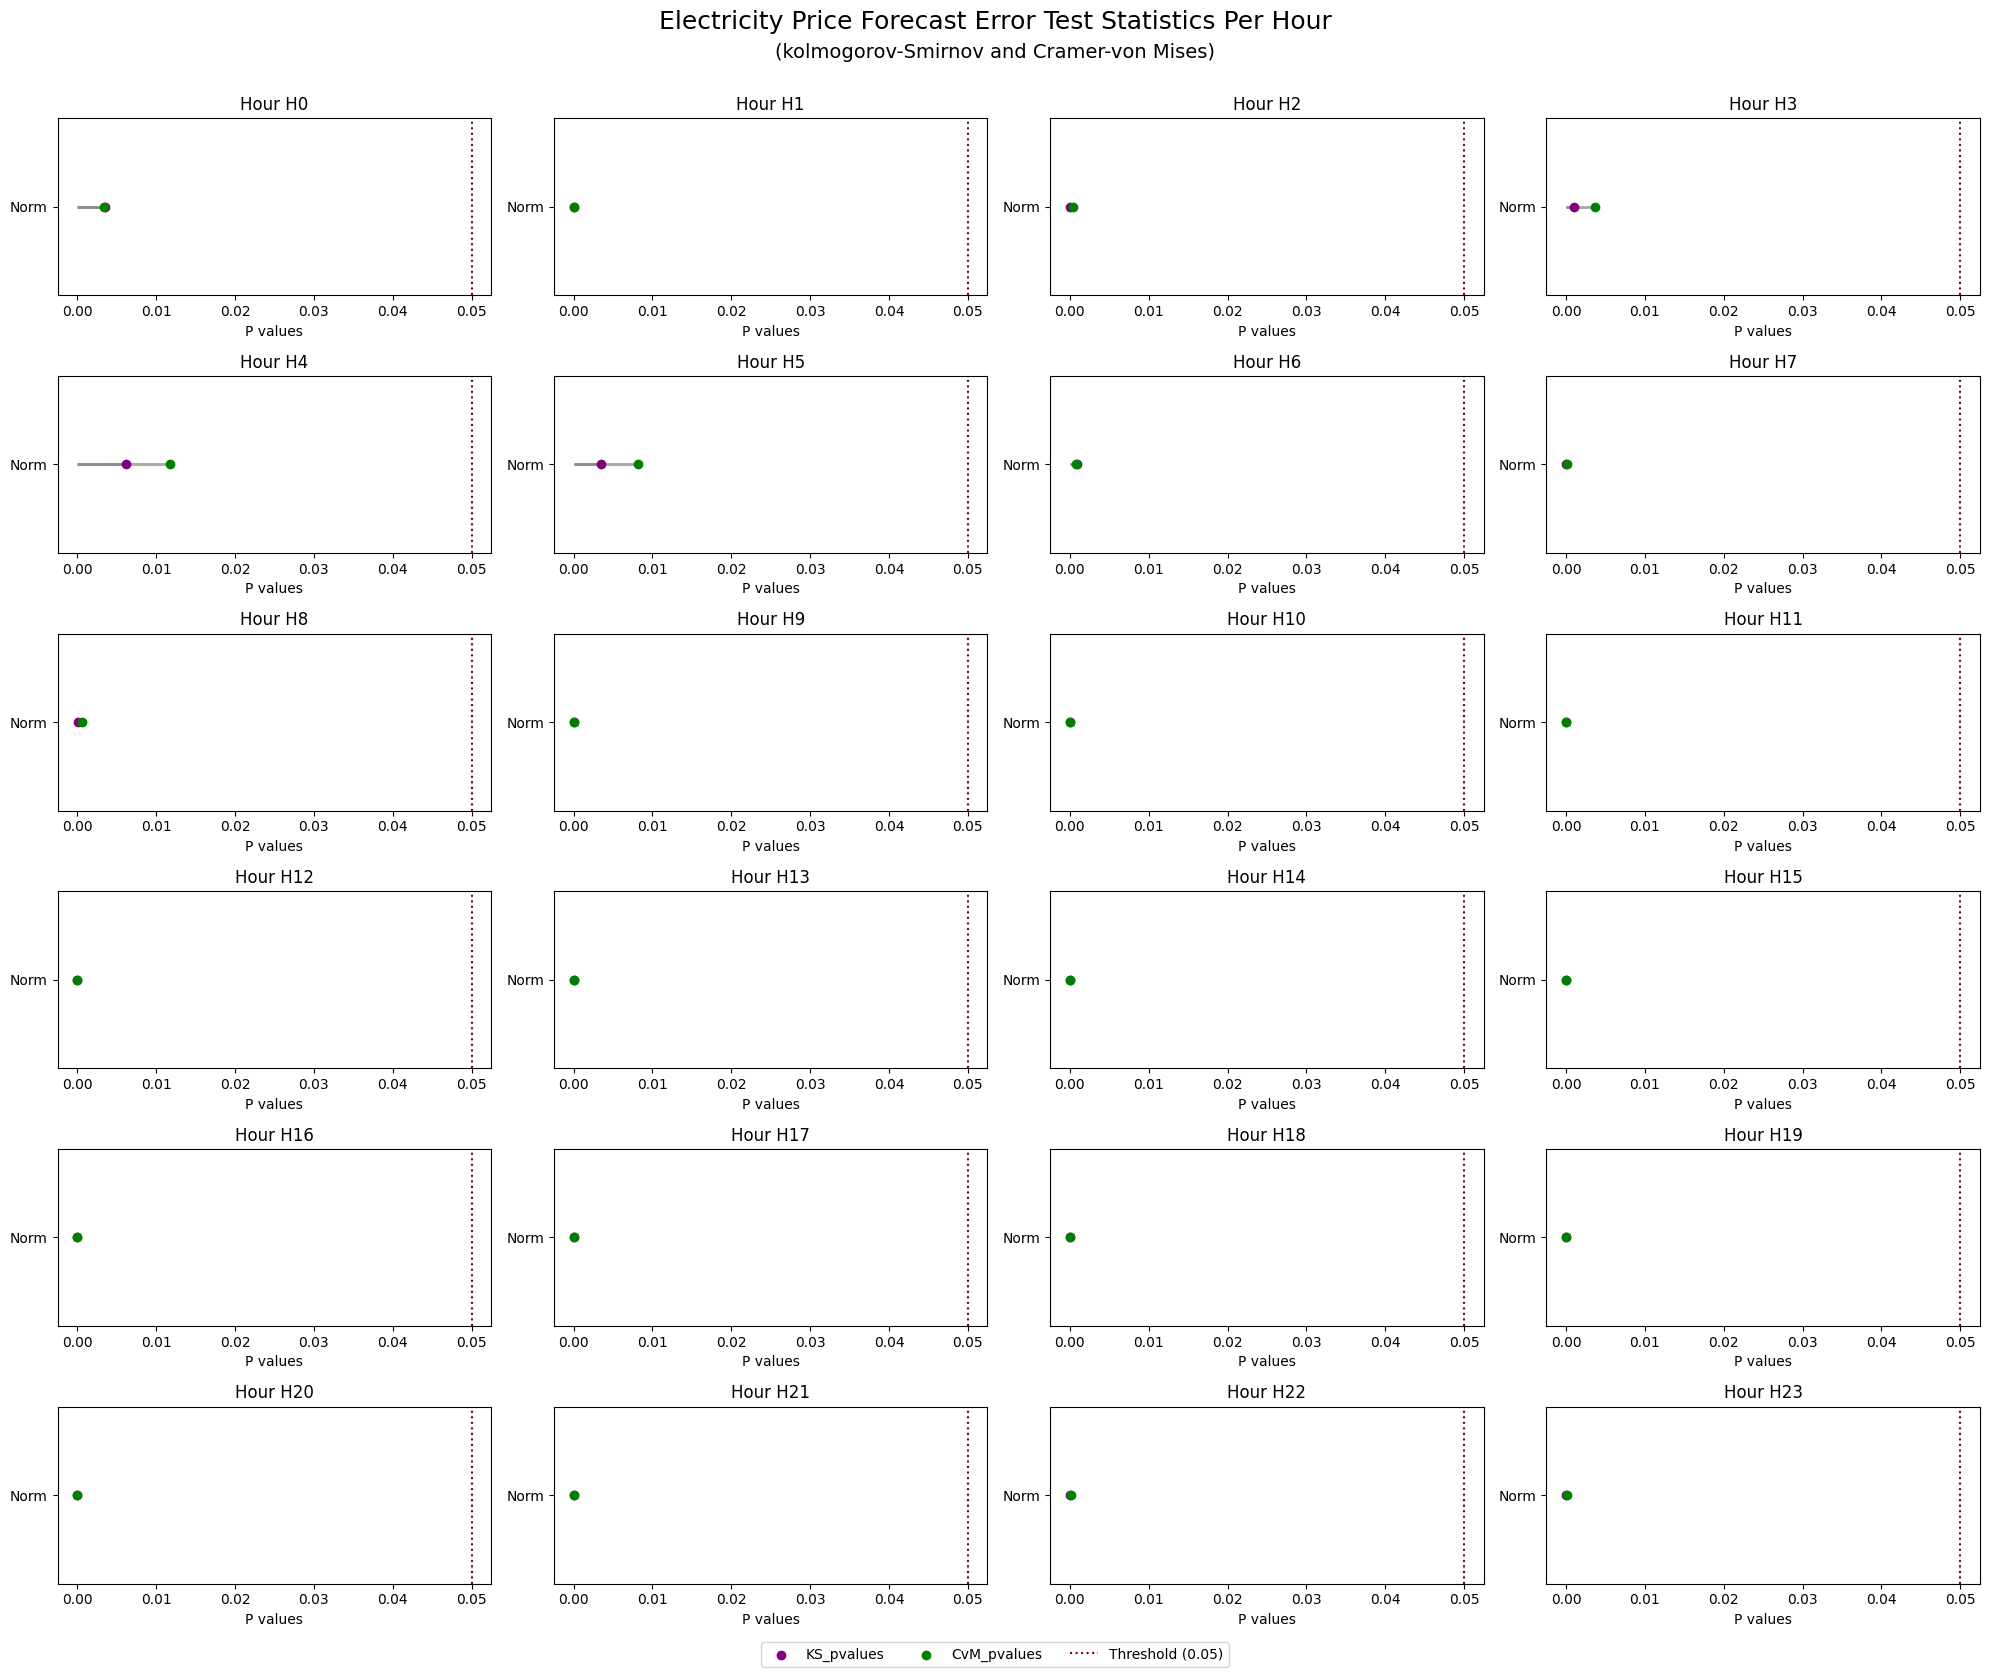

In [ ]:
# Convert data to DataFrame
df_1 = df_pivot_pvalues

# Sort DataFrame by 'KS_pvalues' and 'CvM_pvalues' in descending order
df_sorted = df_1.sort_values(by=['CvM_pvalues', 'KS_pvalues'], ascending=True)

# Create a lollipop plot
fig, axs = plt.subplots(6, 4, figsize=(20, 16))

# Flatten the axs array
axs_flat = axs.flat

# Iterate over each Hour
for i, hour in enumerate(df_1['Hour'].unique()):
    # Filter data for the current hour
    hour_data = df_sorted[df_sorted['Hour'] == hour]

    # Set up subplot
    ax = next(axs_flat)

    # Plot the KS pvalues
    ax.scatter(hour_data['KS_pvalues'], hour_data['PDF'], color='purple', label='KS_pvalues', zorder=5)
    for _, row in hour_data.iterrows():
        ax.hlines(row['PDF'], 0, row['KS_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Plot the CvM pvalues
    ax.scatter(hour_data['CvM_pvalues'], hour_data['PDF'], color='green', label='CvM_pvalues', zorder=5)
    for _, row in hour_data.iterrows():
        ax.hlines(row['PDF'], 0, row['CvM_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Set labels and title
    ax.set_xlabel('P values')
    ax.set_ylabel('')
    ax.set_title(f'Hour {hour}')

    # Place a vertical dotted line at the value of 0.05
    ax.axvline(x=0.05, color='maroon', linestyle='dotted', label='Threshold (0.05)')

    # Disable legend
    ax.legend().remove()

# Add a title and subtitle to the figure
fig.suptitle('Electricity Price Forecast Error Test Statistics Per Hour', fontsize=18, y=1.02)
fig.text(0.5, 0.99, '(kolmogorov-Smirnov and Cramer-von Mises)', ha='center', fontsize=14)

# Add legend at the bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('Error_Price_test_stats_per_hour.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Filtering the 'stats' columns

stats_columns = [col for col in df.columns if 'stats' in col]

# Subset the DataFrame with the filtered column names
df_stats = df[stats_columns].copy()

# Create a range of datetime values from Hour 0 to Hour 23
hours = ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']

# Add the 'Hour' column to the DataFrame
df_stats.loc[:, 'Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
df_stats = df_stats[['Hour'] + [col for col in df_stats.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(df_stats)

        Hour  Norm_KS_stats  Norm_CvM_stats
Hour_0    H0       0.122015        0.942022
Hour_1    H1       0.154424        1.631334
Hour_2    H2       0.156220        1.352047
Hour_3    H3       0.133848        0.924243
Hour_4    H4       0.116378        0.713680
Hour_5    H5       0.122016        0.779157
Hour_6    H6       0.134708        1.214969
Hour_7    H7       0.155627        1.655968
Hour_8    H8       0.147854        1.270967
Hour_9    H9       0.182220        2.080821
Hour_10  H10       0.328463        7.434313
Hour_11  H11       0.283099        5.384564
Hour_12  H12       0.347018        8.189311
Hour_13  H13       0.329557        7.924294
Hour_14  H14       0.401712       11.913892
Hour_15  H15       0.336541        8.483485
Hour_16  H16       0.412295       12.129692
Hour_17  H17       0.377708       11.204129
Hour_18  H18       0.365537       10.245000
Hour_19  H19       0.282506        5.746687
Hour_20  H20       0.208592        3.108405
Hour_21  H21       0.158943     

In [ ]:
# Reshaping the stats column to a 'long' format

import pandas as pd

# Reshape the DataFrame to long format
df_long = pd.melt(df_stats, id_vars='Hour', var_name='PDF', value_name='Value')

# Convert 'Hour' column to categorical type to preserve order
df_long['Hour'] = pd.Categorical(df_long['Hour'], categories=['H{}'.format(i) for i in range(24)], ordered=True)

# Splitting the PDF column into two separate columns
pdf_split = df_long['PDF'].str.split('_', expand=True)

# Assigning the split columns to 'PDF' and 'Stat'
df_long['PDF'] = pdf_split[0]
df_long['Stat'] = pdf_split[1]

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_kstats = df_long.pivot_table(index=['Hour', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_kstats.columns.name = None
df_pivot_kstats.columns = ['Hour', 'PDF', 'CvM_stats', 'KS_stats']

# Arrange PDFs in ascending order of KS_stats and CvM_stats for each year
df_pivot_kstats = df_pivot_kstats.groupby('Hour').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)

# Write to a csv file
df_pivot_kstats.to_csv('Error_Price_KS_CvM_stats_All_hours.csv')

print(df_pivot_kstats)

   Hour   PDF  CvM_stats  KS_stats
0    H0  Norm   0.942022  0.122015
1    H1  Norm   1.631334  0.154424
2    H2  Norm   1.352047  0.156220
3    H3  Norm   0.924243  0.133848
4    H4  Norm   0.713680  0.116378
5    H5  Norm   0.779157  0.122016
6    H6  Norm   1.214969  0.134708
7    H7  Norm   1.655968  0.155627
8    H8  Norm   1.270967  0.147854
9    H9  Norm   2.080821  0.182220
10  H10  Norm   7.434313  0.328463
11  H11  Norm   5.384564  0.283099
12  H12  Norm   8.189311  0.347018
13  H13  Norm   7.924294  0.329557
14  H14  Norm  11.913892  0.401712
15  H15  Norm   8.483485  0.336541
16  H16  Norm  12.129692  0.412295
17  H17  Norm  11.204129  0.377708
18  H18  Norm  10.245000  0.365537
19  H19  Norm   5.746687  0.282506
20  H20  Norm   3.108405  0.208592
21  H21  Norm   1.570890  0.158943
22  H22  Norm   1.553331  0.156072
23  H23  Norm   1.610369  0.162860


<ipython-input-38-2d5bc94d1bfc>:26: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_pivot_kstats = df_pivot_kstats.groupby('Hour').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)


In [ ]:
# PDF parameters for each fitted PDF

pdf_parameters_price

{'Hour_0': {'norm': (7.139003558930896, 5.77874199591529)},
 'Hour_1': {'norm': (6.006158306485131, 5.578048076800503)},
 'Hour_2': {'norm': (6.677181801932199, 6.202730721748368)},
 'Hour_3': {'norm': (6.948285773867654, 5.717186397434706)},
 'Hour_4': {'norm': (7.966906496683756, 5.85967059776625)},
 'Hour_5': {'norm': (8.905368903205508, 6.918846933876075)},
 'Hour_6': {'norm': (10.593939958844866, 9.577732778404629)},
 'Hour_7': {'norm': (12.863093714208647, 12.672947130623285)},
 'Hour_8': {'norm': (12.55757047117031, 11.205913606409972)},
 'Hour_9': {'norm': (14.183997769158008, 15.608929992566226)},
 'Hour_10': {'norm': (17.672826468296314, 39.759768517742344)},
 'Hour_11': {'norm': (17.167872760087114, 29.900013417446896)},
 'Hour_12': {'norm': (21.024911348193474, 53.441447772550134)},
 'Hour_13': {'norm': (21.612468921995383, 48.97438365831804)},
 'Hour_14': {'norm': (43.74861442038541, 175.6198615374956)},
 'Hour_15': {'norm': (30.086571523253266, 71.20885625519279)},
 'Hour

In [ ]:
pdf_data = pd.DataFrame(pdf_parameters_price).T
pdf_data

,norm
Hour_0,"(7.139003558930896, 5.77874199591529)"
Hour_1,"(6.006158306485131, 5.578048076800503)"
Hour_2,"(6.677181801932199, 6.202730721748368)"
Hour_3,"(6.948285773867654, 5.717186397434706)"
Hour_4,"(7.966906496683756, 5.85967059776625)"
Hour_5,"(8.905368903205508, 6.918846933876075)"
Hour_6,"(10.593939958844866, 9.577732778404629)"
Hour_7,"(12.863093714208647, 12.672947130623285)"
Hour_8,"(12.55757047117031, 11.205913606409972)"
Hour_9,"(14.183997769158008, 15.608929992566226)"


In [ ]:
# Unpacking PDF parameters to a 'wider' format

df = pdf_data.copy()

# New DataFrame to store transformed data
new_pdf_data = pd.DataFrame()

# Function to split column based on length of content
def split_columns(hour_data, pdf_name):
    new_columns = {}
    if len(hour_data) == 2:
        new_columns[f'{pdf_name}_loc'] = hour_data[0]
        new_columns[f'{pdf_name}_scale'] = hour_data[1]
    elif len(hour_data) == 3:
        new_columns[f'{pdf_name}_shape'] = hour_data[0]
        new_columns[f'{pdf_name}_loc'] = hour_data[1]
        new_columns[f'{pdf_name}_scale'] = hour_data[2]
    elif len(hour_data) == 4:
        new_columns[f'{pdf_name}_shape1'] = hour_data[0]
        new_columns[f'{pdf_name}_shape2'] = hour_data[1]
        new_columns[f'{pdf_name}_loc'] = hour_data[2]
        new_columns[f'{pdf_name}_scale'] = hour_data[3]
    else:
        raise ValueError(f"Invalid length of content: {len(hour_data)}")
    return new_columns

# Iterate over each hour's data
for hour in range(24):
    hour_data = df.loc[f'Hour_{hour}']

    # Process each column
    for column in hour_data.index:
        pdf_name = column
        new_columns = split_columns(hour_data[column], pdf_name)

        # Add new columns to the new dataframe
        for new_column_name, new_column_data in new_columns.items():
            new_pdf_data.loc[f'Hour_{hour}', new_column_name] = new_column_data

In [ ]:
new_pdf_data

,norm_loc,norm_scale
Hour_0,7.139004,5.778742
Hour_1,6.006158,5.578048
Hour_2,6.677182,6.202731
Hour_3,6.948286,5.717186
Hour_4,7.966906,5.859671
Hour_5,8.905369,6.918847
Hour_6,10.593940,9.577733
Hour_7,12.863094,12.672947
Hour_8,12.557570,11.205914
Hour_9,14.183998,15.608930


In [ ]:
# Create a range of datetime values from 2013 to 2019

hours = ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']

# Add the 'Year' column to the DataFrame
new_pdf_data['Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
new_pdf_data = new_pdf_data[['Hour'] + [col for col in new_pdf_data.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(new_pdf_data)

        Hour   norm_loc  norm_scale
Hour_0    H0   7.139004    5.778742
Hour_1    H1   6.006158    5.578048
Hour_2    H2   6.677182    6.202731
Hour_3    H3   6.948286    5.717186
Hour_4    H4   7.966906    5.859671
Hour_5    H5   8.905369    6.918847
Hour_6    H6  10.593940    9.577733
Hour_7    H7  12.863094   12.672947
Hour_8    H8  12.557570   11.205914
Hour_9    H9  14.183998   15.608930
Hour_10  H10  17.672826   39.759769
Hour_11  H11  17.167873   29.900013
Hour_12  H12  21.024911   53.441448
Hour_13  H13  21.612469   48.974384
Hour_14  H14  43.748614  175.619862
Hour_15  H15  30.086572   71.208856
Hour_16  H16  65.714858  232.455813
Hour_17  H17  40.385265  122.149776
Hour_18  H18  21.505234   62.407150
Hour_19  H19  16.864544   29.152170
Hour_20  H20  13.212066   16.272969
Hour_21  H21   7.952916    7.775764
Hour_22  H22   7.803161    7.102499
Hour_23  H23   8.262183    8.268200


* Process of obtaining the parameters of the **best** PDF for each hour

In [ ]:
# Get the Highest CVM and KS Pvalues for each hour.
max_indices = df_pivot_pvalues.groupby('Hour')[['CvM_pvalues']].idxmax()

# Extract rows with maximum values
max_values_data = df_pivot_pvalues.loc[max_indices.values.flatten()].reset_index(drop=True)

print(max_values_data)

   Hour   PDF   CvM_pvalues    KS_pvalues
0    H0  Norm  3.322679e-03  3.498160e-03
1    H1  Norm  8.292064e-05  7.719111e-05
2    H2  Norm  3.650810e-04  6.085635e-05
3    H3  Norm  3.661503e-03  9.652408e-04
4    H4  Norm  1.172194e-02  6.192896e-03
5    H5  Norm  8.138089e-03  3.497722e-03
6    H6  Norm  7.597680e-04  8.749092e-04
7    H7  Norm  7.291281e-05  4.682547e-05
8    H8  Norm  5.633786e-04  1.323061e-04
9    H9  Norm  7.801446e-06  8.888277e-07
10  H10  Norm  6.030227e-10  2.354697e-21
11  H11  Norm  2.036359e-10  7.013510e-16
12  H12  Norm  4.050171e-11  7.486010e-24
13  H13  Norm  2.012412e-11  1.694003e-21
14  H14  Norm  9.619467e-10  3.983144e-32
15  H15  Norm  8.365875e-11  2.010693e-22
16  H16  Norm  1.337368e-09  6.865658e-34
17  H17  Norm  3.135202e-10  2.525657e-28
18  H18  Norm  2.736563e-09  1.688010e-26
19  H19  Norm  7.013952e-10  8.161443e-16
20  H20  Norm  3.619720e-08  9.251953e-09
21  H21  Norm  1.143256e-04  2.957317e-05
22  H22  Norm  1.254624e-04  4.404

In [ ]:
# Where the magic happens!!!

# Load dataset1 and dataset2
dataset1 = max_values_data.copy()
dataset2 = new_pdf_data.copy()

# Convert PDF column in dataset1 to lowercase
dataset1['PDF'] = dataset1['PDF'].str.lower()

# Initialize dictionary to store results
results_price = {}

# Iterate through each row in dataset1
for index, row in dataset1.iterrows():
    hour = row['Hour']
    pdf = row['PDF']

    # Get the corresponding row from dataset2 for the current hour
    dataset2_row = dataset2.loc[dataset2['Hour'] == hour]

    # Create a dictionary to store column names and their corresponding values from dataset2
    matching_columns = {}

    # Search for columns in dataset2 for the corresponding hour that start with the PDF value
    for column in dataset2_row.columns:
        if column.lower().startswith(pdf):
            matching_columns[column] = dataset2_row.iloc[0][column]

    # Add the dictionary to the results with hour as the key
    results_price[hour] = matching_columns

# Print the results
for hour, columns_data in results_price.items():
    print(f"For Hour {hour}:")
    if columns_data:
        print("Matching Columns in dataset2:")
        for column, value in columns_data.items():
            print(f"{column}: {value}")
    else:
        print("No matching columns found in dataset2 for this hour and PDF.")
    print()

For Hour H0:
Matching Columns in dataset2:
norm_loc: 7.139003558930896
norm_scale: 5.77874199591529

For Hour H1:
Matching Columns in dataset2:
norm_loc: 6.006158306485131
norm_scale: 5.578048076800503

For Hour H2:
Matching Columns in dataset2:
norm_loc: 6.677181801932199
norm_scale: 6.202730721748368

For Hour H3:
Matching Columns in dataset2:
norm_loc: 6.948285773867654
norm_scale: 5.717186397434706

For Hour H4:
Matching Columns in dataset2:
norm_loc: 7.966906496683756
norm_scale: 5.85967059776625

For Hour H5:
Matching Columns in dataset2:
norm_loc: 8.905368903205508
norm_scale: 6.918846933876075

For Hour H6:
Matching Columns in dataset2:
norm_loc: 10.593939958844866
norm_scale: 9.577732778404629

For Hour H7:
Matching Columns in dataset2:
norm_loc: 12.863093714208647
norm_scale: 12.672947130623285

For Hour H8:
Matching Columns in dataset2:
norm_loc: 12.55757047117031
norm_scale: 11.205913606409972

For Hour H9:
Matching Columns in dataset2:
norm_loc: 14.183997769158008
norm_sca

In [ ]:
# New dictionary with keys ranging from 0 to 23
electricity_price_data = {}

# Iterate over the original dictionary and map keys to range(24)
for hour_str, hour_data in results_price.items():
    # Extract the hour number from the key
    hour = int(hour_str[1:])
    electricity_price_data[hour] = hour_data

# Print the new dictionary
electricity_price_data

{0: {'norm_loc': 7.139003558930896, 'norm_scale': 5.77874199591529},
 1: {'norm_loc': 6.006158306485131, 'norm_scale': 5.578048076800503},
 2: {'norm_loc': 6.677181801932199, 'norm_scale': 6.202730721748368},
 3: {'norm_loc': 6.948285773867654, 'norm_scale': 5.717186397434706},
 4: {'norm_loc': 7.966906496683756, 'norm_scale': 5.85967059776625},
 5: {'norm_loc': 8.905368903205508, 'norm_scale': 6.918846933876075},
 6: {'norm_loc': 10.593939958844866, 'norm_scale': 9.577732778404629},
 7: {'norm_loc': 12.863093714208647, 'norm_scale': 12.672947130623285},
 8: {'norm_loc': 12.55757047117031, 'norm_scale': 11.205913606409972},
 9: {'norm_loc': 14.183997769158008, 'norm_scale': 15.608929992566226},
 10: {'norm_loc': 17.672826468296314, 'norm_scale': 39.759768517742344},
 11: {'norm_loc': 17.167872760087114, 'norm_scale': 29.900013417446896},
 12: {'norm_loc': 21.024911348193474, 'norm_scale': 53.441447772550134},
 13: {'norm_loc': 21.612468921995383, 'norm_scale': 48.97438365831804},
 14: 

In [ ]:
import pickle

# File path to save the dictionary
file_path = "priceerror_data_norm.pickle"

# Save the dictionary to a file
with open(file_path, 'wb') as file:
    pickle.dump(electricity_price_data, file)